# Chapter 12.3: World Models for Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand world models as learned simulators of user behavior
2. Build an environment model that predicts user responses to recommendations
3. Implement counterfactual simulation for offline policy evaluation
4. Use world models for planning with look-ahead optimization
5. Train recommendation policies using learned simulators
6. Evaluate the fidelity of world models against real user behavior
7. Apply model-based RL techniques to optimize long-term engagement

## Prerequisites

- Understanding of reinforcement learning basics (Part 10)
- Knowledge of sequence modeling with Transformers (Part 6)
- Familiarity with policy optimization methods
- PyTorch proficiency

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part12/chapter_12.3_world_models.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part12/chapter_12.3_world_models.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict
import copy

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cpu')

print("All imports successful!")

All imports successful!


## 1. What is a World Model for Recommendation?

A **world model** is a learned simulator that predicts how users respond to recommendations.
Instead of directly optimizing the recommendation policy, we first learn the environment dynamics,
then plan within the learned model.

### The Recommendation MDP

- **State** $s_t$: User's current context (history, preferences, mood)
- **Action** $a_t$: Items recommended at step $t$
- **Transition** $s_{t+1} = T(s_t, a_t)$: How user state evolves
- **Reward** $r_t = R(s_t, a_t)$: User engagement (click, purchase, satisfaction)

The world model learns:

$$\hat{s}_{t+1}, \hat{r}_t = f_\theta(s_t, a_t)$$

> **💡 Concept:** World models enable *imagination-based planning*. Instead of interacting with
> real users (expensive, slow, risky), we simulate thousands of user trajectories in the learned
> model to find the best recommendation strategy.

In [2]:
# Define a synthetic user environment
class UserEnvironment:
    """Simulates user behavior for recommendation."""
    
    def __init__(self, n_users=200, n_items=100, n_categories=5, state_dim=16):
        self.n_users = n_users
        self.n_items = n_items
        self.n_categories = n_categories
        self.state_dim = state_dim
        
        # True user preferences (hidden)
        self.user_prefs = np.random.randn(n_users, state_dim) * 0.5
        # Item features
        self.item_features = np.random.randn(n_items, state_dim) * 0.5
        # Item categories
        self.item_categories = np.random.randint(0, n_categories, n_items)
        # Satisfaction decay (users get bored of same category)
        self.satiation_rate = 0.15
        
    def reset(self, user_id):
        """Reset environment for a user."""
        state = {
            'user_id': user_id,
            'preferences': self.user_prefs[user_id].copy(),
            'category_counts': np.zeros(self.n_categories),
            'step': 0,
            'total_reward': 0.0
        }
        return self._encode_state(state), state
    
    def _encode_state(self, state):
        """Encode state as a vector."""
        cat_norm = state['category_counts'] / max(1, state['step'])
        return np.concatenate([
            state['preferences'],
            cat_norm,
            [state['step'] / 20.0]
        ])
    
    def step(self, state, action):
        """Take action (recommend item), return reward and next state."""
        item_feat = self.item_features[action]
        cat = self.item_categories[action]
        
        # Base relevance
        relevance = np.dot(state['preferences'], item_feat)
        
        # Satiation: reduce reward for over-recommended categories
        cat_penalty = self.satiation_rate * state['category_counts'][cat]
        reward = float(np.clip(relevance - cat_penalty + np.random.randn() * 0.1, -1, 1))
        
        # State transition
        new_state = copy.deepcopy(state)
        new_state['category_counts'][cat] += 1
        new_state['step'] += 1
        # User preferences drift slightly based on interaction
        new_state['preferences'] += 0.01 * item_feat * (1 if reward > 0 else -1)
        new_state['total_reward'] += reward
        
        done = new_state['step'] >= 20
        next_obs = self._encode_state(new_state)
        
        return next_obs, reward, done, new_state

env = UserEnvironment()
obs, state = env.reset(0)
print(f"Observation dim: {obs.shape[0]}")
obs2, reward, done, state2 = env.step(state, action=5)
print(f"Reward: {reward:.4f}, Done: {done}")

Observation dim: 22
Reward: 0.5117, Done: False


## 2. Learning the World Model

We train a neural network to approximate the environment dynamics:

$$\hat{r}_t = R_\theta(s_t, a_t) \quad \text{(reward model)}$$
$$\hat{s}_{t+1} = T_\theta(s_t, a_t) \quad \text{(transition model)}$$

Training objective:

$$\mathcal{L} = \mathbb{E}\left[\|\hat{s}_{t+1} - s_{t+1}\|^2 + (\hat{r}_t - r_t)^2\right]$$

> **⚠️ Common Pitfall:** World model errors compound over multi-step predictions. A model that is
> 95% accurate per step can be wildly inaccurate after 10 steps. Use ensemble models and limit
> planning horizon.

In [3]:
# Collect training data from the environment
def collect_trajectories(env, n_episodes=500, random_policy=True):
    """Collect experience tuples from the environment."""
    transitions = []
    
    for episode in range(n_episodes):
        user_id = np.random.randint(0, env.n_users)
        obs, state = env.reset(user_id)
        
        for t in range(20):
            if random_policy:
                action = np.random.randint(0, env.n_items)
            else:
                # Greedy based on true preference
                scores = env.item_features @ state['preferences']
                action = int(np.argmax(scores))
            
            next_obs, reward, done, next_state = env.step(state, action)
            
            transitions.append({
                'obs': obs.copy(),
                'action': action,
                'reward': reward,
                'next_obs': next_obs.copy(),
                'done': done
            })
            
            obs = next_obs
            state = next_state
            if done:
                break
    
    return transitions

transitions = collect_trajectories(env)
print(f"Collected {len(transitions)} transitions")
print(f"Observation dim: {transitions[0]['obs'].shape}")

Collected 10000 transitions
Observation dim: (22,)


In [4]:
class WorldModel(nn.Module):
    """Neural network world model for user behavior simulation."""
    
    def __init__(self, obs_dim=22, n_items=100, hidden_dim=128, item_embed_dim=16):
        super().__init__()
        self.item_embedding = nn.Embedding(n_items, item_embed_dim)
        
        input_dim = obs_dim + item_embed_dim
        
        # Shared trunk
        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        # Reward prediction head
        self.reward_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        # Next state prediction head
        self.transition_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, obs_dim)
        )
    
    def forward(self, obs, action):
        """Predict reward and next observation."""
        action_emb = self.item_embedding(action)
        x = torch.cat([obs, action_emb], dim=-1)
        hidden = self.trunk(x)
        reward_pred = self.reward_head(hidden).squeeze(-1)
        next_obs_pred = self.transition_head(hidden)
        return reward_pred, next_obs_pred

# Prepare data
class TransitionDataset(Dataset):
    def __init__(self, transitions):
        self.obs = torch.tensor([t['obs'] for t in transitions], dtype=torch.float)
        self.actions = torch.tensor([t['action'] for t in transitions], dtype=torch.long)
        self.rewards = torch.tensor([t['reward'] for t in transitions], dtype=torch.float)
        self.next_obs = torch.tensor([t['next_obs'] for t in transitions], dtype=torch.float)
    
    def __len__(self):
        return len(self.obs)
    
    def __getitem__(self, idx):
        return self.obs[idx], self.actions[idx], self.rewards[idx], self.next_obs[idx]

split = int(0.8 * len(transitions))
train_ds = TransitionDataset(transitions[:split])
val_ds = TransitionDataset(transitions[split:])
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Train: 8000, Val: 2000


/var/folders/fm/hwpyrzvx207290wd3x3n9zgh0000gn/T/ipykernel_78292/3955011026.py:44: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  self.obs = torch.tensor([t['obs'] for t in transitions], dtype=torch.float)


In [5]:
# Train the world model
def train_world_model(model, train_loader, val_loader, n_epochs=30, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'reward_mae': [], 'transition_mse': []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for obs, actions, rewards, next_obs in train_loader:
            reward_pred, next_obs_pred = model(obs, actions)
            reward_loss = F.mse_loss(reward_pred, rewards)
            transition_loss = F.mse_loss(next_obs_pred, next_obs)
            loss = reward_loss + transition_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        model.eval()
        val_loss = 0
        reward_mae = 0
        trans_mse = 0
        n_batches = 0
        with torch.no_grad():
            for obs, actions, rewards, next_obs in val_loader:
                reward_pred, next_obs_pred = model(obs, actions)
                val_loss += (F.mse_loss(reward_pred, rewards) + F.mse_loss(next_obs_pred, next_obs)).item()
                reward_mae += F.l1_loss(reward_pred, rewards).item()
                trans_mse += F.mse_loss(next_obs_pred, next_obs).item()
                n_batches += 1
        
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_loss'].append(val_loss / n_batches)
        history['reward_mae'].append(reward_mae / n_batches)
        history['transition_mse'].append(trans_mse / n_batches)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Val Loss: {val_loss/n_batches:.4f}, "
                  f"Reward MAE: {reward_mae/n_batches:.4f}")
    
    return history

obs_dim = transitions[0]['obs'].shape[0]
world_model = WorldModel(obs_dim=obs_dim, n_items=100)
wm_history = train_world_model(world_model, train_loader, val_loader)

Epoch 10/30 - Val Loss: 0.3345, Reward MAE: 0.4525


Epoch 20/30 - Val Loss: 0.2413, Reward MAE: 0.3653


Epoch 30/30 - Val Loss: 0.2213, Reward MAE: 0.3464


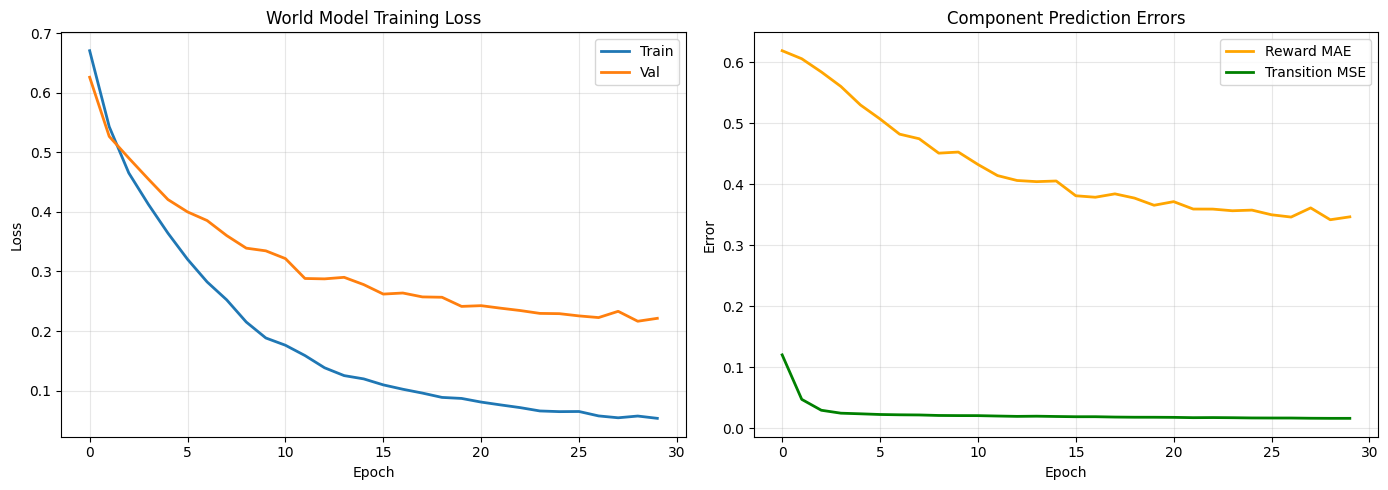

In [6]:
# Visualize world model training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(wm_history['train_loss'], label='Train', linewidth=2)
axes[0].plot(wm_history['val_loss'], label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('World Model Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(wm_history['reward_mae'], label='Reward MAE', linewidth=2, color='orange')
axes[1].plot(wm_history['transition_mse'], label='Transition MSE', linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Error')
axes[1].set_title('Component Prediction Errors')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Counterfactual Simulation

A major use of world models is **counterfactual reasoning**: "What would have happened if we
had shown different items?"

Given a real trajectory $(s_0, a_0, r_0, s_1, a_1, r_1, \ldots)$, we can ask:

$$\hat{r}_t' = R_\theta(s_t, a_t') \quad \text{for alternative action } a_t'$$

> **💡 Concept:** Counterfactual simulation enables offline A/B testing. Instead of running
> a live experiment, simulate what would happen under a new recommendation policy using
> the world model.

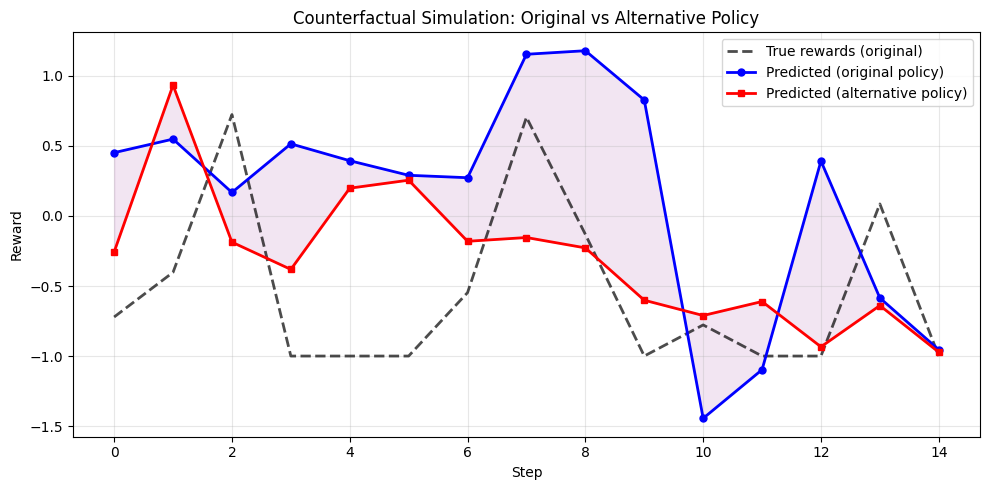

Original policy total predicted reward: 2.1157
Alternative policy total predicted reward: -4.4684


In [7]:
def counterfactual_simulation(world_model, env, user_id, original_actions, alternative_actions):
    """Compare original vs alternative action sequences using the world model."""
    world_model.eval()
    obs, state = env.reset(user_id)
    
    results = {'original': [], 'alternative': [], 'original_true': []}
    
    obs_tensor = torch.tensor(obs, dtype=torch.float).unsqueeze(0)
    obs_alt = obs_tensor.clone()
    
    for t in range(min(len(original_actions), len(alternative_actions))):
        # Original actions - predicted
        with torch.no_grad():
            orig_action = torch.tensor([original_actions[t]], dtype=torch.long)
            alt_action = torch.tensor([alternative_actions[t]], dtype=torch.long)
            
            orig_reward, orig_next = world_model(obs_tensor, orig_action)
            alt_reward, alt_next = world_model(obs_alt, alt_action)
        
        # Original actions - true reward
        _, true_reward, _, state = env.step(state, original_actions[t])
        
        results['original'].append(orig_reward.item())
        results['alternative'].append(alt_reward.item())
        results['original_true'].append(true_reward)
        
        obs_tensor = orig_next
        obs_alt = alt_next
    
    return results

# Run counterfactual simulation
user_id = 0
original_actions = list(np.random.randint(0, 50, 15))  # Random items from first half
alternative_actions = list(np.random.randint(50, 100, 15))  # Random from second half

cf_results = counterfactual_simulation(world_model, env, user_id, original_actions, alternative_actions)

fig, ax = plt.subplots(figsize=(10, 5))
steps = range(len(cf_results['original']))
ax.plot(steps, cf_results['original_true'], 'k--', label='True rewards (original)', linewidth=2, alpha=0.7)
ax.plot(steps, cf_results['original'], 'b-o', label='Predicted (original policy)', linewidth=2, markersize=5)
ax.plot(steps, cf_results['alternative'], 'r-s', label='Predicted (alternative policy)', linewidth=2, markersize=5)
ax.fill_between(steps, cf_results['original'], cf_results['alternative'], alpha=0.1, color='purple')
ax.set_xlabel('Step')
ax.set_ylabel('Reward')
ax.set_title('Counterfactual Simulation: Original vs Alternative Policy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Original policy total predicted reward: {sum(cf_results['original']):.4f}")
print(f"Alternative policy total predicted reward: {sum(cf_results['alternative']):.4f}")

## 4. Planning with World Models

With a learned world model, we can **plan ahead** to find the best action at each step
by simulating multiple futures:

$$a_t^* = \arg\max_{a_t} \mathbb{E}\left[\sum_{k=0}^{H} \gamma^k \hat{r}_{t+k}\right]$$

This is Model Predictive Control (MPC) applied to recommendation.

> **🔑 Pro Tip:** Use the world model for short-horizon planning (3-5 steps) where prediction
> errors are manageable. For longer horizons, combine with a value function learned from
> simulated trajectories.

In [8]:
def model_predictive_control(world_model, current_obs, n_items=100,
                              horizon=3, n_samples=50, gamma=0.95):
    """Use the world model for look-ahead planning."""
    world_model.eval()
    best_action = 0
    best_value = float('-inf')
    
    with torch.no_grad():
        # Evaluate random action sequences
        for _ in range(n_samples):
            obs = current_obs.clone()
            # Random first action
            first_action = np.random.randint(0, n_items)
            action_tensor = torch.tensor([first_action], dtype=torch.long)
            
            total_value = 0
            reward_pred, obs = world_model(obs.unsqueeze(0), action_tensor)
            total_value += reward_pred.item()
            obs = obs.squeeze(0)
            
            # Simulate remaining horizon with random actions
            for h in range(1, horizon):
                random_action = torch.tensor([np.random.randint(0, n_items)], dtype=torch.long)
                r, obs = world_model(obs.unsqueeze(0), random_action)
                total_value += (gamma ** h) * r.item()
                obs = obs.squeeze(0)
            
            if total_value > best_value:
                best_value = total_value
                best_action = first_action
    
    return best_action, best_value


def evaluate_policies(env, world_model, n_episodes=50):
    """Compare random, greedy, and MPC policies."""
    results = {'random': [], 'greedy': [], 'mpc': []}
    
    for ep in range(n_episodes):
        user_id = np.random.randint(0, env.n_users)
        
        for policy_name in ['random', 'greedy', 'mpc']:
            obs, state = env.reset(user_id)
            total_reward = 0
            
            for t in range(20):
                if policy_name == 'random':
                    action = np.random.randint(0, env.n_items)
                elif policy_name == 'greedy':
                    # Score all items using world model (1-step lookahead)
                    obs_tensor = torch.tensor(obs, dtype=torch.float).unsqueeze(0)
                    with torch.no_grad():
                        all_actions = torch.arange(env.n_items)
                        obs_expanded = obs_tensor.expand(env.n_items, -1)
                        rewards, _ = world_model(obs_expanded, all_actions)
                    action = int(rewards.argmax().item())
                else:  # MPC
                    obs_tensor = torch.tensor(obs, dtype=torch.float)
                    action, _ = model_predictive_control(world_model, obs_tensor, n_items=env.n_items)
                
                obs, reward, done, state = env.step(state, action)
                total_reward += reward
                if done:
                    break
            
            results[policy_name].append(total_reward)
    
    return results

policy_results = evaluate_policies(env, world_model, n_episodes=30)

for policy, rewards in policy_results.items():
    print(f"{policy:8s}: Mean={np.mean(rewards):.3f}, Std={np.std(rewards):.3f}")

random  : Mean=-4.559, Std=3.534
greedy  : Mean=13.349, Std=5.580
mpc     : Mean=9.875, Std=2.897


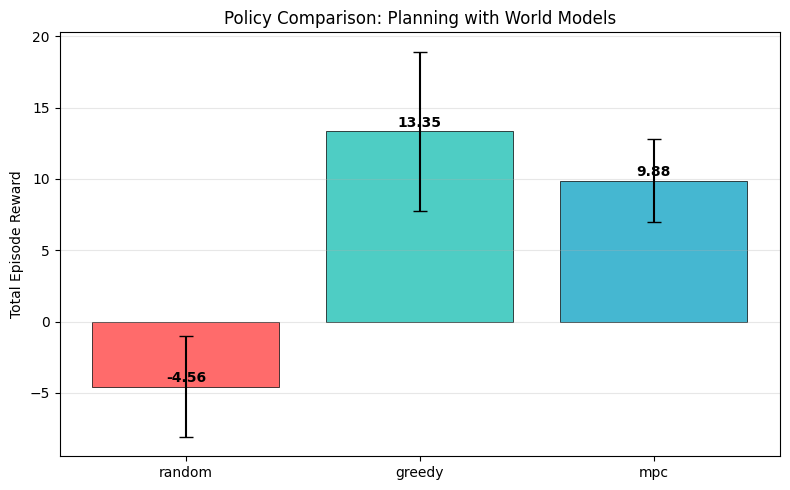

In [9]:
# Visualize policy comparison
fig, ax = plt.subplots(figsize=(8, 5))
policies = list(policy_results.keys())
means = [np.mean(policy_results[p]) for p in policies]
stds = [np.std(policy_results[p]) for p in policies]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(policies, means, yerr=stds, capsize=5, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Total Episode Reward')
ax.set_title('Policy Comparison: Planning with World Models')
ax.grid(True, alpha=0.3, axis='y')

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{mean:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Policy Optimization with Learned Simulator

Instead of planning at inference time, we can use the world model to **train a policy network**
entirely in simulation (Dyna-style RL).

$$\theta_{\pi}^* = \arg\max_{\theta_{\pi}} \mathbb{E}_{\text{world model}}\left[\sum_t \gamma^t r_t\right]$$

> **⚠️ Common Pitfall:** Policies trained purely in the world model can exploit model errors.
> Always validate against real environment interactions or held-out data.

In [10]:
class PolicyNetwork(nn.Module):
    """Simple policy network for recommendation."""
    def __init__(self, obs_dim=22, n_items=100, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_items)
        )
    
    def forward(self, obs):
        return self.net(obs)
    
    def select_action(self, obs, temperature=1.0):
        logits = self.forward(obs) / temperature
        probs = F.softmax(logits, dim=-1)
        action = torch.multinomial(probs, 1)
        return action.squeeze(-1), probs


def train_policy_in_world_model(policy, world_model, obs_dim, n_items=100,
                                 n_iterations=200, horizon=10, batch_size=32, lr=1e-3):
    """Train policy using REINFORCE in the learned world model."""
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    rewards_history = []
    
    for iteration in range(n_iterations):
        # Simulate trajectories in the world model
        obs = torch.randn(batch_size, obs_dim) * 0.3
        total_rewards = torch.zeros(batch_size)
        log_probs_sum = torch.zeros(batch_size)
        
        for t in range(horizon):
            action, probs = policy.select_action(obs, temperature=1.0)
            log_prob = torch.log(probs.gather(1, action.unsqueeze(1)).squeeze(1) + 1e-8)
            log_probs_sum += log_prob
            
            with torch.no_grad():
                reward_pred, next_obs_pred = world_model(obs, action)
            
            total_rewards += reward_pred.detach() * (0.95 ** t)
            obs = next_obs_pred.detach()
        
        # REINFORCE
        baseline = total_rewards.mean()
        advantage = total_rewards - baseline
        policy_loss = -(log_probs_sum * advantage.detach()).mean()
        
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()
        
        rewards_history.append(total_rewards.mean().item())
        
        if (iteration + 1) % 50 == 0:
            print(f"Iteration {iteration+1}/{n_iterations} - Mean reward: {rewards_history[-1]:.4f}")
    
    return rewards_history

policy = PolicyNetwork(obs_dim=obs_dim, n_items=100)
policy_rewards = train_policy_in_world_model(policy, world_model, obs_dim=obs_dim)

Iteration 50/200 - Mean reward: -0.8741


Iteration 100/200 - Mean reward: -0.9673


Iteration 150/200 - Mean reward: -0.5803


Iteration 200/200 - Mean reward: 1.4049


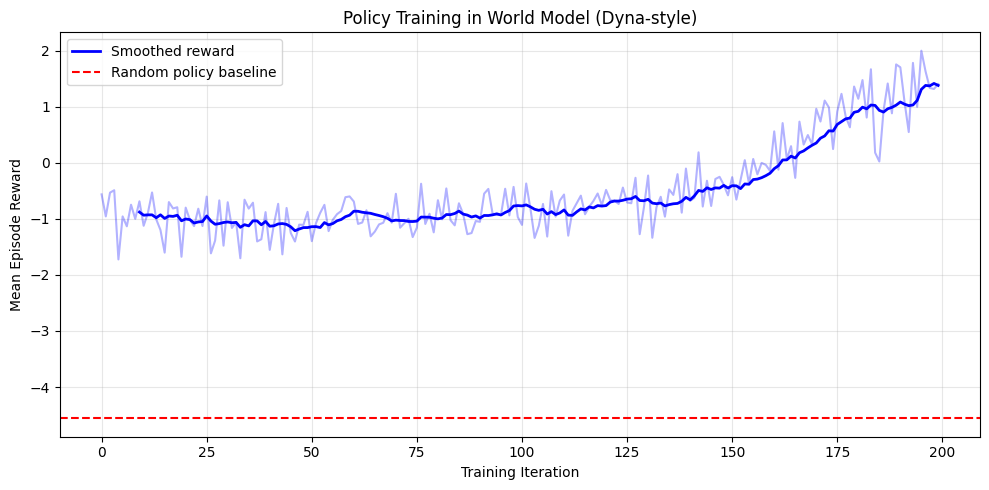

In [11]:
# Visualize policy learning
fig, ax = plt.subplots(figsize=(10, 5))
window = 10
smoothed = np.convolve(policy_rewards, np.ones(window)/window, mode='valid')
ax.plot(policy_rewards, alpha=0.3, color='blue')
ax.plot(range(window-1, len(policy_rewards)), smoothed, linewidth=2, color='blue', label='Smoothed reward')
ax.axhline(y=np.mean(policy_results['random']), color='red', linestyle='--', label='Random policy baseline')
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Mean Episode Reward')
ax.set_title('Policy Training in World Model (Dyna-style)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🏋️ Exercise 1: Build an Ensemble World Model

Train an ensemble of $K$ world models and use disagreement as an uncertainty estimate.
This helps detect when the policy is visiting states where the model is unreliable.

In [12]:
# TODO: Build an ensemble world model
class EnsembleWorldModel:
    def __init__(self, n_models=5, obs_dim=22, n_items=100):
        # TODO: Create n_models independent WorldModel instances
        pass
    
    def predict(self, obs, action):
        # TODO: Get predictions from all models
        # Return mean prediction and uncertainty (std across models)
        pass
    
    def train_ensemble(self, train_loader, n_epochs=20):
        # TODO: Train each model on bootstrap samples
        pass

print("Exercise 1: Implement EnsembleWorldModel")

Exercise 1: Implement EnsembleWorldModel


## 🏋️ Exercise 2: Model Fidelity Evaluation

Evaluate how well the world model matches the real environment over multi-step rollouts.
Plot the prediction error as a function of rollout horizon.

In [13]:
# TODO: Evaluate world model fidelity
def evaluate_model_fidelity(world_model, env, n_episodes=20, max_horizon=15):
    """Measure prediction error over increasing horizons."""
    # TODO:
    # 1. For each episode, run both real env and world model in parallel
    # 2. At each step, measure reward prediction error and state prediction error
    # 3. Return errors as a function of horizon
    pass

# TODO: Plot error vs horizon
print("Exercise 2: Implement model fidelity evaluation")

Exercise 2: Implement model fidelity evaluation


## 🏋️ Exercise 3: Implement Dyna-Q Style Training

Combine real and simulated experience: use real environment interactions for model learning,
and world model rollouts for policy improvement.

In [14]:
# TODO: Implement Dyna-Q for recommendation
def dyna_training(env, world_model, policy, n_real_steps=100, n_sim_steps_per_real=5):
    """Dyna-style training loop."""
    # TODO:
    # 1. Take a real step in the environment
    # 2. Add real transition to replay buffer
    # 3. Update world model with real data
    # 4. Generate n_sim_steps simulated transitions from world model
    # 5. Update policy with both real and simulated data
    pass

print("Exercise 3: Implement Dyna-Q training")

Exercise 3: Implement Dyna-Q training


## Summary

In this notebook, we explored world models for recommendation:

1. **User behavior simulators**: Learning to predict how users respond to recommendations
2. **World model training**: Joint reward and transition prediction
3. **Counterfactual simulation**: Offline evaluation of alternative policies
4. **Planning with MPC**: Look-ahead optimization using the world model
5. **Policy training in simulation**: Dyna-style RL with learned simulators

### Key Takeaways

- World models enable safe exploration: test new strategies without affecting real users
- Model errors compound over time: use ensembles and limit planning horizon
- Combine real and simulated data for robust policy learning
- Counterfactual reasoning is invaluable for understanding recommendation impact